In [1]:
from src.QDDPM_torch_angel import DiffusionModel, QDDPM, WassDistance
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch
import time

import matplotlib.pyplot as plt
from matplotlib import rc
# rc('text', usetex=True)
rc('axes', linewidth=3)

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# This label will identificate the files generated in this notebook. E.g. if you work only with 0 and 1 digits, use '01'.
customlabel = '01' 
T = 22 # Nr of time steps
epochs = 5000

# THIS TRANSFORMATION WILL DETERMINE THE NR OF QUBITS NEEDED (at least 2^n_pixels):
transform = transforms.Compose([transforms.Resize(8), transforms.ToTensor()])
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
fail to load cloud provider module: tencent


CUDA available: True
CUDA device: NVIDIA RTX 6000 Ada Generation


Sample shape: torch.Size([1, 8, 8]), Label: 0
Number of pixels in the image: 64
Number of qubits needed: 6


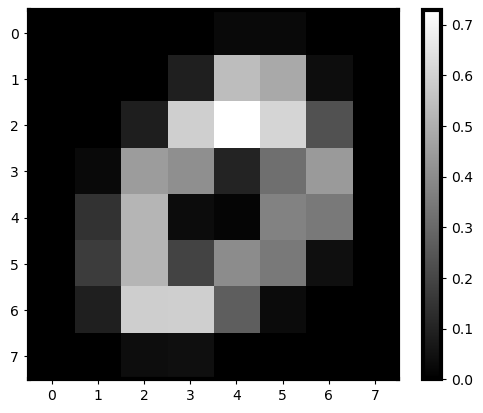

In [2]:
# Plot just the first sample

import matplotlib.pyplot as plt

sample, label = mnist[1]
plt.imshow(sample.squeeze(), cmap='gray')
plt.colorbar()

print(f"Sample shape: {sample.shape}, Label: {label}")
print(f"Number of pixels in the image: {sample.numel()}")
print(f"Number of qubits needed: {int(np.ceil(np.log2(sample.numel())))}")

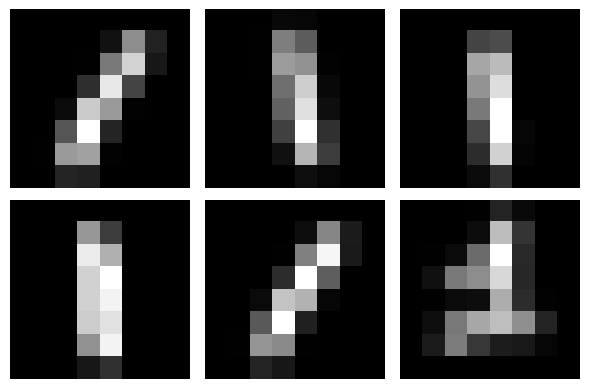

In [3]:
N = 6

dataset = mnist
indices = [i for i, (img, label) in enumerate(dataset) if label == 1]
dataset = Subset(dataset, indices)

fig, axes = plt.subplots(2, N//2, figsize=(6, 4))
for i in range(N):
    sample, label = dataset[i]
    axes[i//(N//2), i%(N//2)].imshow(sample.squeeze(), cmap='gray')
    # axes[i//(N//2), i%(N//2)].set_title(f"Label: {label}")
    axes[i//(N//2), i%(N//2)].axis('off')

plt.tight_layout()